# Задание 9 — рабочий вариант
Ниже код генерирует строку, рисует символы и собирает итоговое изображение. Также строятся 2 дополнительных графика для визуализации параметров.


In [1]:
import random
import string
import numpy as np
import matplotlib.pyplot as plt

# Для повторяемости результата
random.seed(42)
np.random.seed(42)


Matplotlib is building the font cache; this may take a moment.


In [2]:
def generate_string(length: int) -> str:
    """Генерирует случайную строку из латинских букв."""
    alphabet = string.ascii_uppercase
    return ''.join(random.choice(alphabet) for _ in range(length))


In [3]:
def render_letter(letter: str, size: int = 40, fg=(30, 90, 180), bg=(255, 255, 255)) -> np.ndarray:
    """Рендерит одну букву в виде RGB-картинки numpy."""
    # белый фон
    canvas = np.ones((size, size, 3), dtype=np.uint8)
    canvas[:] = np.array(bg, dtype=np.uint8)

    # Рисуем букву через matplotlib в буфер
    fig, ax = plt.subplots(figsize=(1, 1), dpi=size)
    ax.set_facecolor(np.array(bg)/255)
    ax.text(0.5, 0.5, letter, fontsize=28, ha='center', va='center', color=np.array(fg)/255)
    ax.axis('off')
    fig.tight_layout(pad=0)
    fig.canvas.draw()

    data = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    data = data.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    return data


In [4]:
def combine_images(images, spacing: int = 12, bg=(255, 255, 255)) -> np.ndarray:
    """Склеивает список RGB-картинок в одну строку с отступами."""
    h = max(img.shape[0] for img in images)
    w = sum(img.shape[1] for img in images) + spacing * (len(images) - 1)
    out = np.ones((h, w, 3), dtype=np.uint8)
    out[:] = np.array(bg, dtype=np.uint8)
    x = 0
    for img in images:
        out[:img.shape[0], x:x+img.shape[1]] = img
        x += img.shape[1] + spacing
    return out


Сгенерированная строка: UDAXIHHEXD


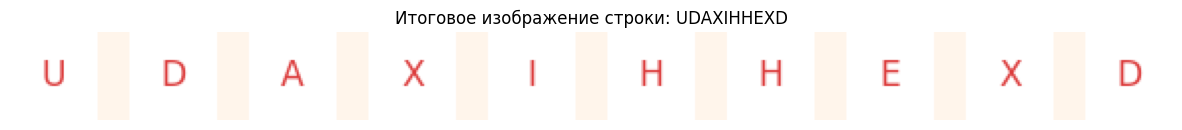

In [5]:
# Параметры
str_size = 10
text = generate_string(str_size)
print('Сгенерированная строка:', text)

# Цвета (можно менять)
foreground = (220, 60, 60)   # цвет букв
background = (255, 245, 235) # цвет фона

letters = [render_letter(ch, size=44, fg=foreground, bg=background) for ch in text]
result = combine_images(letters, spacing=16, bg=background)

plt.figure(figsize=(15, 3))
plt.imshow(result)
plt.axis('off')
plt.title(f'Итоговое изображение строки: {text}')
plt.show()


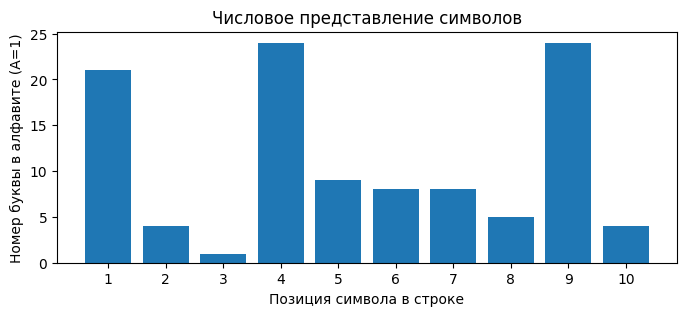

In [6]:
# Доп. график 1: распределение индексов букв в алфавите
idx = np.array([string.ascii_uppercase.index(ch) + 1 for ch in text])
plt.figure(figsize=(8, 3))
plt.bar(range(1, len(idx)+1), idx)
plt.xticks(range(1, len(idx)+1))
plt.xlabel('Позиция символа в строке')
plt.ylabel('Номер буквы в алфавите (A=1)')
plt.title('Числовое представление символов')
plt.show()


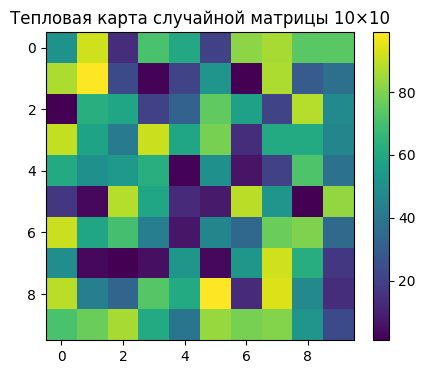

In [7]:
# Доп. график 2: случайный массив и его тепловая карта
mat = np.random.randint(0, 100, (10, 10))
plt.figure(figsize=(5, 4))
plt.imshow(mat)
plt.colorbar()
plt.title('Тепловая карта случайной матрицы 10×10')
plt.show()
